# CEM run from a `.xy` shoreline

Self-contained CEM workflow: reads a shoreline from a simple two-column `.xy`
file (x y, in projected meters), runs coupled CEM+Waves, and shows results with
a **before/after comparison** and a **lightweight animation** (subsampled
frames, no slow GIF render).

This is the self-contained template: one `.xy` file + this notebook, no external
data pipeline. To use a different shoreline, just point Section 3 at a
different `.xy` file.

**Kernel:** one with `Cem`/`Waves` + `scipy` (the `pymt` kernel works).


## 1. Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import path
from matplotlib.animation import FuncAnimation
from scipy.spatial import cKDTree
import time
%matplotlib inline
print("imports OK")

imports OK


## 2. Optimized `shorelinetogrid` (KD-Tree)

Same `x, y, dx, dy` -> `xg, yg, zg` interface as the original, but uses a
KD-Tree for the nearest-neighbor distance (~30x faster than the double loop).

In [2]:
def shorelinetogrid_fast(x, y, dx, dy):
    """xy shoreline -> gridded Dean-profile depth field. Returns (xg, yg, zg)."""
    x = np.asarray(x, float); y = np.asarray(y, float)
    A = 0.1; rng = 100000
    x0 = int(np.ceil(min(x)/dx)*dx); y0 = int(np.ceil(min(y)/dy)*dy)
    x1 = x0 + int(np.ceil((max(x)-min(x))/dx)*dx - 2*dx)
    y1 = y0 + int(np.ceil((max(y)-min(y))/dy)*dy + 5000)
    xg, yg = np.meshgrid(list(range(x0,x1,dx)), list(range(y0,y1,dy)),
                         sparse=False, indexing='ij')
    tree = cKDTree(np.column_stack([x, y]))
    nn, _ = tree.query(np.column_stack([xg.ravel(), yg.ravel()]),
                       k=1, distance_upper_bound=rng)
    nn[np.isinf(nn)] = np.sqrt(1.e10)
    dist = nn.reshape(xg.shape)
    zg = -A * dist**(2/3)
    p = path.Path(np.transpose([x, y]))
    IN = p.contains_points(np.transpose([xg.flatten(), yg.flatten()])).reshape(xg.shape)
    zg[IN] = (np.min(A * (dist[IN])**(2/3))) + 1
    return xg, yg, zg * -1

print("shorelinetogrid_fast defined")

shorelinetogrid_fast defined


## 3. Load the shoreline (`.xy` file)

A plain two-column text file: `x y` per line, in projected meters (UTM). To run
a different shoreline, change `XY_PATH`.

lon range: -80.1861 to -80.0394
lat range: 42.0942 to 42.1682


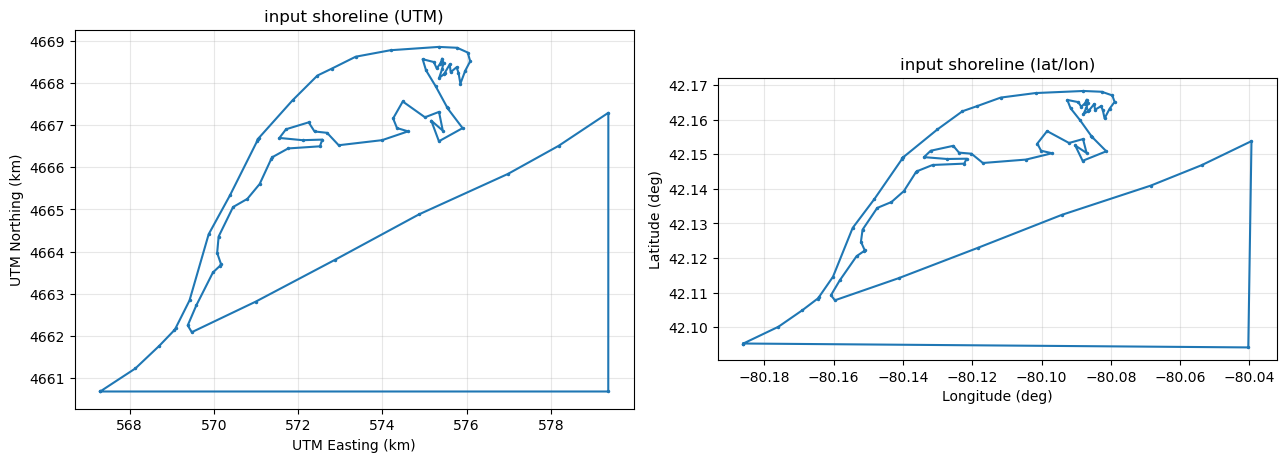

In [3]:
# --- load data (so this cell is self-contained) ---
XY_PATH = "Erie_spit_ESPIn.xy"
dx = dy = 100

data = np.loadtxt(XY_PATH)
x, y = data[:, 0], data[:, 1]

# --- two versions (UTM + lat/lon) ---
# Assumes UTM Zone 17N (Erie). Change the EPSG code for other data.
UTM_EPSG = 32617   # 17N; 18N=32618, 16N=32616, southern hemisphere uses 327xx

# Try to convert to lat/lon with pyproj
try:
    from pyproj import Transformer
    tf = Transformer.from_crs(UTM_EPSG, 4326, always_xy=True)
    lon, lat = tf.transform(x, y)
    have_lonlat = True
except Exception as e:
    have_lonlat = False
    print("pyproj unavailable, plotting UTM only:", e)

if have_lonlat:
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))
else:
    fig, ax1 = plt.subplots(figsize=(7, 5))

# Left: UTM, shown in kilometers, no 1e6 offset
ax1.plot(x/1000, y/1000, '.-', ms=3)
ax1.set_aspect('equal')
ax1.set_xlabel("UTM Easting (km)")
ax1.set_ylabel("UTM Northing (km)")
ax1.set_title("input shoreline (UTM)")
ax1.ticklabel_format(style='plain', useOffset=False)  # turn off sci notation and offset
ax1.grid(True, alpha=0.3)

# Right: lat/lon
if have_lonlat:
    ax2.plot(lon, lat, '.-', ms=3)
    ax2.set_aspect('equal')
    ax2.set_xlabel("Longitude (deg)")
    ax2.set_ylabel("Latitude (deg)")
    ax2.set_title("input shoreline (lat/lon)")
    ax2.ticklabel_format(style='plain', useOffset=False)
    ax2.grid(True, alpha=0.3)
    print(f"lon range: {lon.min():.4f} to {lon.max():.4f}")
    print(f"lat range: {lat.min():.4f} to {lat.max():.4f}")

plt.tight_layout()
plt.show()

## 4. Build the initial grid

grid shape: (119, 132)  (15708 cells) in 0.0103s


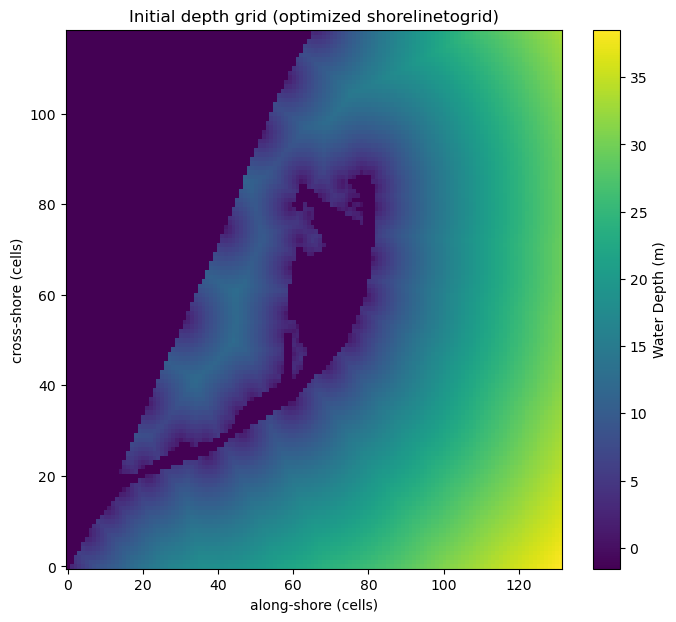

In [4]:
t0 = time.perf_counter()
xg, yg, zg = shorelinetogrid_fast(x, y, dx, dy)
print(f"grid shape: {zg.shape}  ({zg.size} cells) in {time.perf_counter()-t0:.4f}s")

plt.figure(figsize=(8, 7))
im = plt.imshow(zg, origin="lower", cmap="viridis", aspect="auto")
plt.colorbar(im, label="Water Depth (m)")
plt.title("Initial depth grid (optimized shorelinetogrid)")
plt.xlabel("along-shore (cells)"); plt.ylabel("cross-shore (cells)")
plt.show()

## 5. Initialize CEM + Waves

Verified variable names for pymt_cem 0.1.3 (v0). Domain convention: land > 0,
water < 0, so we negate and transpose `zg`.

In [5]:
from pymt.models import Cem, Waves

waves = Waves()
cem = Cem()

domain = -1.0 * zg.T.copy()        # land > 0, water < 0
n_rows, n_cols = domain.shape
print("domain shape (rows, cols):", domain.shape)

args = cem.setup(number_of_rows=n_rows, number_of_cols=n_cols, grid_spacing=float(dx))
waves.initialize(*waves.setup())
cem.initialize(*args)

wave_height = 1.5
wave_period = 7.0
waves.set_value("sea_surface_water_wave__height", wave_height)
waves.set_value("sea_surface_water_wave__period", wave_period)
waves.set_value("sea_shoreline_wave~incoming~deepwater__ashton_et_al_approach_angle_highness_parameter", 0.5)
waves.set_value("sea_shoreline_wave~incoming~deepwater__ashton_et_al_approach_angle_asymmetry_parameter", 0.5)

cem.set_value("sea_surface_water_wave__height", wave_height)
cem.set_value("sea_surface_water_wave__period", wave_period)
cem.set_value("land_surface__elevation", domain.flatten())

print("CEM + Waves initialized")

domain shape (rows, cols): (132, 119)
CEM + Waves initialized


Setting end time to 3650
CEM: trying to open file: cem.txt
CEM: line: 132, 119, 100.0, 1

CEM: number of rows, columns: 132, 119
*** Grid size is (0,0)
*** Requested size is (132,238)
*** New grid size is (132,238)
/opt/tljh/user/envs/pymt/lib/python3.11/site-packages/xarray/core/utils.py:494: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  warnings.warn(


## 6. Run, capturing frames sparsely (lightweight)

Run the model and **save the state only every `SAVE_EVERY` steps** instead of
every step. The C core is fast; only plotting is slow, so ~20-40 frames stays
quick.

Note: pymt_cem 0.1.3 is the v0 build with the shadow bug that crashes some
shorelines past ~100-120 steps. Erie is stable at 100. If it crashes, lower
`N_STEPS`.

In [6]:
N_STEPS    = 100    # Erie is stable at 100; raise cautiously (v0 bug past ~120)
SAVE_EVERY = 5      # capture a frame every N steps

alpha = "sea_surface_water_wave__azimuth_angle_of_opposite_of_phase_velocity"

qs = np.zeros((n_rows, n_cols))
qs[0, n_cols // 2] = 500.0     # sediment source at one cell (0 array = none)

frames = []
t0 = time.perf_counter()
for t in range(N_STEPS):
    waves.update()
    cem.set_value(alpha, waves.get_value(alpha))
    cem.set_value("land_surface_water_sediment~bedload__mass_flow_rate", qs)
    cem.update()
    if t % SAVE_EVERY == 0 or t == N_STEPS - 1:
        z = cem.get_value("sea_water__depth").reshape(domain.shape).copy()
        frames.append((t, z))

print(f"ran {N_STEPS} steps in {time.perf_counter()-t0:.2f}s, captured {len(frames)} frames")

ran 100 steps in 0.38s, captured 21 frames


## 7. Before / after (static)

In [7]:
# --- Visualization helpers (run once) ---
import numpy as np
import matplotlib.colors as mcolors
from matplotlib.lines import Line2D

def pick_frames(target_steps):
    """Return [(actual_step, grid), ...] closest to each requested step."""
    out = []
    for s in target_steps:
        idx = min(range(len(frames)), key=lambda i: abs(frames[i][0] - s))
        out.append(frames[idx])
    return out

# default 3 timepoints: start, middle, end
last = frames[-1][0]
KEY_STEPS = [0, last // 2, last]
print("frames available:", [f[0] for f in frames])
print("showing steps:", [f[0] for f in pick_frames(KEY_STEPS)])

frames available: [0, 5, 10, 15, 20, 25, 30, 35, 40, 45, 50, 55, 60, 65, 70, 75, 80, 85, 90, 95, 99]
showing steps: [0, 50, 99]


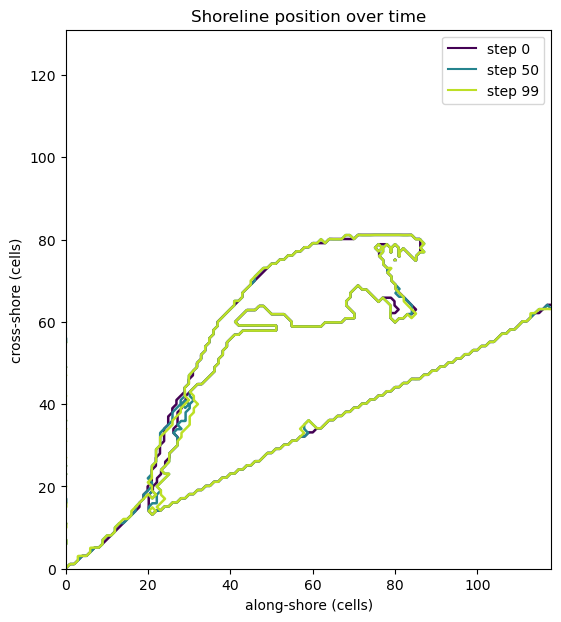

In [8]:
# --- 1) Shoreline position over time ---
fig, ax = plt.subplots(figsize=(9, 7))
colors = plt.cm.viridis(np.linspace(0, 0.9, len(KEY_STEPS)))
handles = []
for c, (step, z) in zip(colors, pick_frames(KEY_STEPS)):
    ax.contour(z, levels=[0], colors=[c], linewidths=1.8)
    handles.append(Line2D([0], [0], color=c, label=f"step {step}"))
ax.set_aspect('equal')
ax.set_xlabel("along-shore (cells)"); ax.set_ylabel("cross-shore (cells)")
ax.set_title("Shoreline position over time")
ax.legend(handles=handles)
plt.show()

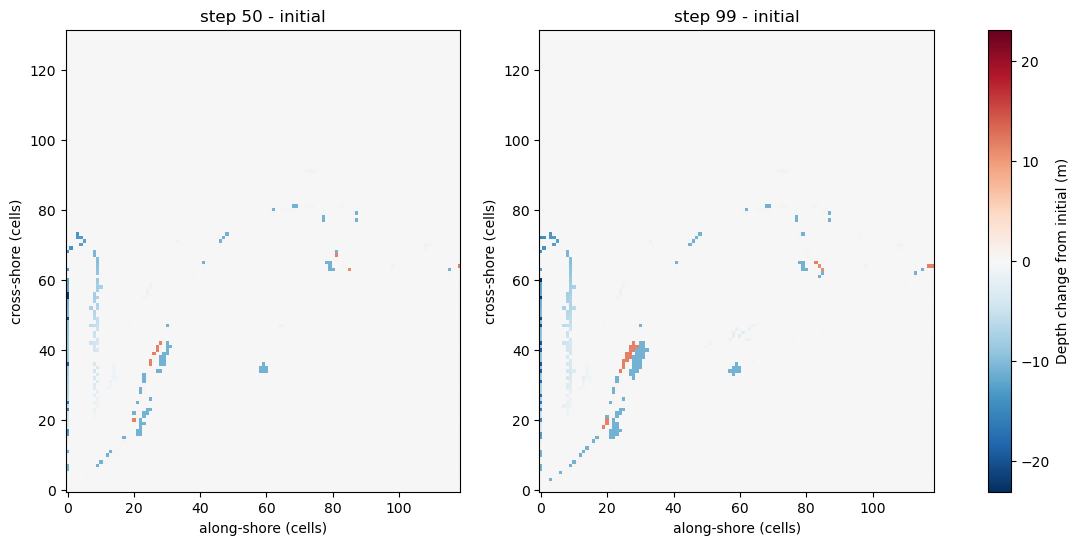

In [9]:
# --- 2) Change from initial (erosion/accretion) ---
z0 = frames[0][1]
panels = [(f"step {s} - initial", z - z0) for s, z in pick_frames(KEY_STEPS[1:])]

dmax = max(np.abs(p[1]).max() for p in panels)
norm = mcolors.TwoSlopeNorm(vmin=-dmax, vcenter=0, vmax=dmax)

fig, axes = plt.subplots(1, len(panels), figsize=(7*len(panels), 6), squeeze=False)
for ax, (label, dz) in zip(axes[0], panels):
    im = ax.imshow(dz, origin="lower", cmap="RdBu_r", norm=norm, aspect="auto")
    ax.set_title(label)
    ax.set_xlabel("along-shore (cells)"); ax.set_ylabel("cross-shore (cells)")
fig.colorbar(im, ax=axes[0], label="Depth change from initial (m)")
plt.show()

## 8. Lightweight animation (inline, no GIF by default)

`FuncAnimation` over the sparse captured frames, displayed inline. Far lighter
than ArtistAnimation over hundreds of frames + a GIF save. To save a GIF,
uncomment the last line (only then does it pay the encode cost).

In [10]:
# --- 3) Lightweight animation: shoreline moving over time ---
from matplotlib.animation import FuncAnimation
plt.rcParams["animation.html"] = "jshtml"

z0 = frames[0][1]
dmax = max(np.abs(z - z0).max() for _, z in frames)
norm = mcolors.TwoSlopeNorm(vmin=-dmax, vcenter=0, vmax=dmax)

fig, ax = plt.subplots(figsize=(8, 7))
im = ax.imshow(frames[0][1] - z0, origin="lower", cmap="RdBu_r",
               norm=norm, aspect="auto")
cl = ax.contour(frames[0][1], levels=[0], colors='black', linewidths=1.2)
ax.set_xlabel("along-shore (cells)"); ax.set_ylabel("cross-shore (cells)")
fig.colorbar(im, ax=ax, label="Depth change from initial (m)")
title = ax.set_title("")

def _update(i):
    step, z = frames[i]
    im.set_data(z - z0)
    for coll in ax.collections[1:]:
        coll.remove()
    ax.contour(z, levels=[0], colors='black', linewidths=1.2)
    title.set_text(f"step {step}")
    return [im]

anim = FuncAnimation(fig, _update, frames=len(frames), interval=200, blit=False)
plt.close(fig)
anim
# To save: anim.save("evolution.gif", writer="pillow", fps=5)

## Notes

- If a shoreline **crashes with `xtest is uninitialized!`**, that's the v0
  shadow bug; lower `N_STEPS`. It's geometry-dependent, so different shorelines
  tolerate different step counts.
- Portable env for DCC:
  `mamba create -n cemrun -c conda-forge python=3.11 pymt pymt_cem numpy scipy matplotlib ipykernel`
